# SIMPLE REGRESSION ANALYSIS

Marketing ROI analaysis using TV, Radio and Social Media as features. dependent variable/ target variable is Sales, while the independent variables/features are TV, Radio and Social Media. The goal of this project is to recommed the marketing channel with the strongest ROI impact

# import libraries and packages

**pandas for data manipulation**

**statsmodels for statistical modeling**

**seaborn for plotting**

# Import packages
import pandas as pd
import numpy as np
import seaborn as sns

In [21]:
# Load dataset
marketing = pd.read_csv("marketing.csv")

# Examine first 5 rows of dataset
marketing.head(10)

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
5,29.0,9.614382,1.027163,105.889148
6,55.0,24.893811,4.273602,198.679825
7,31.0,17.355042,2.289855,108.733932
8,76.0,24.648898,7.130116,270.189400
9,13.0,0.431128,2.229423,48.280582


In [22]:
#examine the shape of the data
marketing.shape

(4572, 4)

In [23]:
#examine the size of the data
marketing.size

18288

In [24]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [25]:
marketing.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [26]:
marketing.columns

Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='object')


# DATA CLEANING

In [27]:
marketing.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

# drop all missing values in datasets

In [30]:
marketing.dropna(inplace=True)

In [31]:
marketing.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

# Exploratory data analysis

<Axes: >

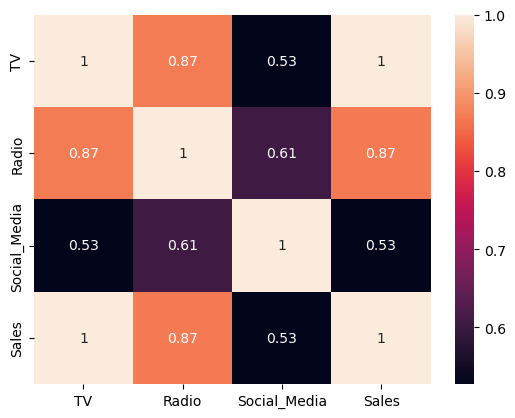

In [35]:
# create a heatmap of the dataset
sns.heatmap(marketing.corr(), annot=True)

**from the heatmap**
This gives a visual explanation of the correlation between TV, Social_Media and Radio. TV has an almost perfect correlation with Sales
TV has a higher impact on sales

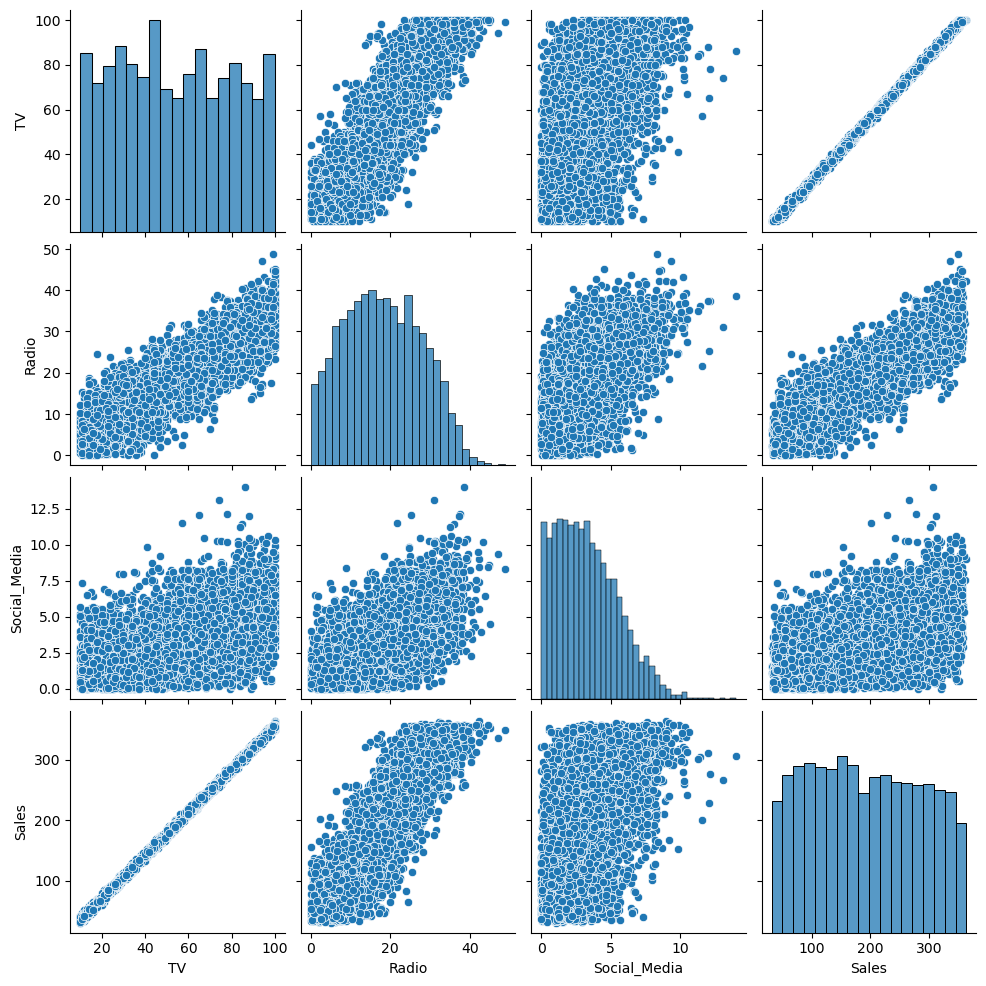

In [32]:
# Create pairwise scatterplots of data set
sns.pairplot(marketing)

From the scatterplot matrix, you can observe a few linear relationships:
* TV and Sales ( almost perfectly linear)
* TV and Radio
* Radio and Sales
* Social Media and Radio

# Model development

Based on the above scatterplots, we could probably run a simple linear regression on any of the three relationships identified. For this project our focus  will be on the relationship between TV and Sales as they are the most linearly correlated

To do this, we first subset the variables of interest from the dataframe by using double square brackets [[]], and listing the names of the columns of interest.

In [36]:
# Subset Data


ols_data = marketing[['TV', 'Sales']]

Next, we can construct the linear regression formula
* Dependent variable y = Sales
* Independent Variable X = TV

In [37]:
# Write out formula
ols_formula = "Sales ~ TV"

y = mx + c +e

**Let's  build the simple linear regression model in statsmodels**

In [39]:
# Import ols function
from statsmodels.formula.api import ols

In [40]:
# Build OLS, fit model to data
OLS = ols(ols_formula, ols_data)
model = OLS.fit()

# Let's get the summary  of the model, coefficients and more statistics about the model. this helps us  evaluate the model and interpret the results

In [41]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:18:42   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# FROM THE OLS SUMMARY

**R-Squared: this indicates that TV explains 99% of Sales Variation**

**TV coef: 3.5615 what this means is that for every 1 unit increase in TV, Sales go up by 3.56 units (i.e 3.5X ROI)**

**P|t| for TV is 0.00, so TV is statistically significant, as p|t| < 0.00 shows a feature is usefulfull/ significant while > 0.00 signals noise**

**DF model = 1, tells us that this is a simple regression model as only one feature was used**

# visual of the regression line.

<Axes: xlabel='TV', ylabel='Sales'>

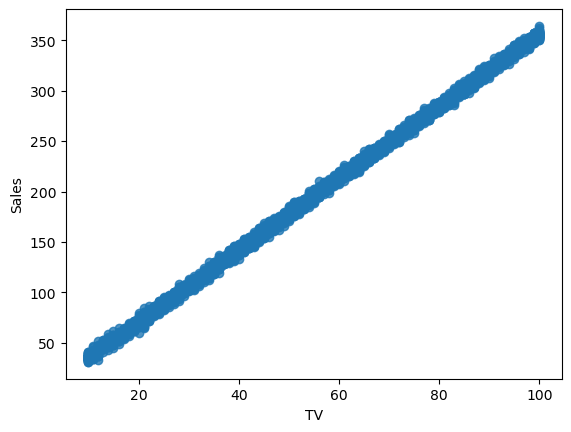

In [43]:
sns.regplot(x = "TV", y = "Sales", data = ols_data)

# model assumptions

1.Linearity

2.Normality

3.Independent observations

4.Homoscedasticity

we already checked the linearity assumption by creating the scatterplot matrix and we observed that TV and Sales assume linearity 

The normality and homoscedasticity assumptions focus on the distribution of errors. Thus, we can only check these assumptions after we have constructed the model. To check these assumptions, we will check the residuals, as an approximation of the errors.

To more easily check the model assumptions and create relevant visualizations.

In [44]:
X = ols_data["TV"]

X.head()

0    16.0
1    13.0
2    41.0
3    83.0
4    15.0
Name: TV, dtype: float64

In [45]:
# Get predictions from model
fitted_values = model.predict(X)

In [46]:
fitted_values

0        56.851733
1        46.167191
2       145.889585
3       295.473177
4        53.290219
           ...    
4567     92.466874
4568    252.735008
4569    156.574128
4570    252.735008
4571    149.451099
Length: 4546, dtype: float64

In [47]:
# Calculate residuals
residuals = model.resid

# Check the normality assumption

From the below histogram, you may notice that the residuals are almost normally distributed. In this case, it is likely close enough that the assumption is met.

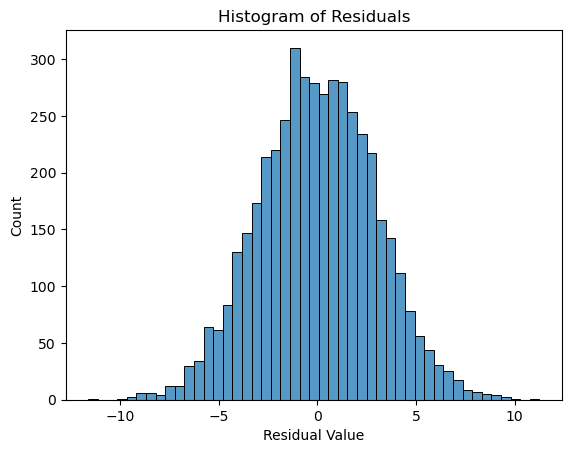

In [49]:
import matplotlib.pyplot as plt
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

Another way to check the normality function is to create a quantile-quantile or Q-Q plot. If the residuals are normally distributed, you would expect a straight diagonal line going from the bottom left to the upper right of the Q-Q plot.

The Q-Q plot shows a similar pattern to the histogram, where the residuals are mostly normally distributed, except at the ends of the distribution.

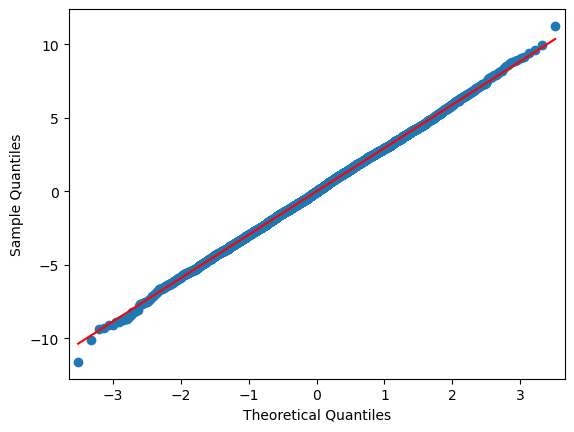

In [50]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
fig = sm.qqplot(model.resid, line = 's')
plt.show()

# Check the homoscedasticity assumption

Lastly, we have to check the homoscedasticity assumption. To check the homoscedasticity assumption, we can create a scatterplot of the fitted values and residuals. If the plot resembles a random cloud (i.e., the residuals are scattered randomly), then the assumption is likely met.

he first argument is the variable that goes on the x-axis. The second argument is the variable that goes on the y-axis.

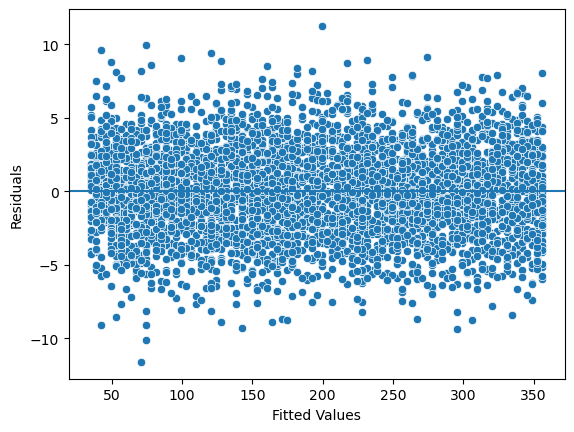

In [51]:
import matplotlib.pyplot as plt
fig = sns.scatterplot(x=fitted_values, y=residuals)

# Add reference line at residuals = 0
fig.axhline(0)

# Set x-axis and y-axis labels
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")

# Show the plot
plt.show()

# RECOMMENDATION
TV is the Dominant driver of Sales in this dataset with 3.523x ROI. The company should prioritize and increase TV budget allocation to maximize Sales revenue.

All OLS assumptions are met- Linearity, normality and homoscedasticity as confirmed by diagnostic plots